# **Sentiment Analysis**


## **Objective**
Build a machine learning model that classifies the sentiment of text data (positive, negative, or neutral), providing insights into public opinion or customer feedback.


### **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

### **Download NLTK Resources**

In [ ]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### **Load the Dataset**

In [ ]:
df = pd.read_csv("Corona_NLP_test.csv")

In [ ]:
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,1,44953,NYC,02-03-2020,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative
1,2,44954,"Seattle, WA",02-03-2020,When I couldn't find hand sanitizer at Fred Me...,Positive
2,3,44955,NaN,02-03-2020,Find out how you can protect yourself and love...,Extremely Positive
3,4,44956,Chicagoland,02-03-2020,#Panic buying hits #NewYork City as anxious sh...,Negative
4,5,44957,"Melbourne, Victoria",03-03-2020,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (3798, 6)

Column Names:
Index(['UserName', 'ScreenName', 'Location', 'TweetAt', 'OriginalTweet',
       'Sentiment'],
      dtype='object')

Missing Values:
UserName           0
ScreenName         0
Location         834
TweetAt            0
OriginalTweet      0
Sentiment          0
dtype: int64

Data Types:
UserName          int64
ScreenName        int64
Location         object
TweetAt          object
OriginalTweet    object
Sentiment        object
dtype: object


### **Inspect Sentiment Classes**

The original sentiment labels are examined before the extreme sentiment categories are combined into Positive and Negative classes.

In [ ]:
df["Sentiment"].value_counts()

,count
Sentiment,
Negative,1041
Positive,947
Neutral,619
Extremely Positive,599
Extremely Negative,592


### **Sentiment Label Standardisation**

The dataset originally contains five sentiment categories. To meet the project requirement of classifying text, as Positive, Negative or Neutral the category " Positive" is combined with the category "Positive" and the category "Extremely Negative" is combined with the category "Negative".

In [ ]:
df["Sentiment"] = df["Sentiment"].str.strip()

df["Sentiment"] = df["Sentiment"].replace({
    "Extremely Positive": "Positive",
    "Extremely Negative": "Negative"
})

print(df["Sentiment"].value_counts())

Sentiment
Negative    1633
Positive    1546
Neutral      619
Name: count, dtype: int64


### **Sentiment Distribution**

The way Positive, Negative and Neutral sentiments were spread out was shown in a chart to get an idea of how balanced the classes are, in the data set.

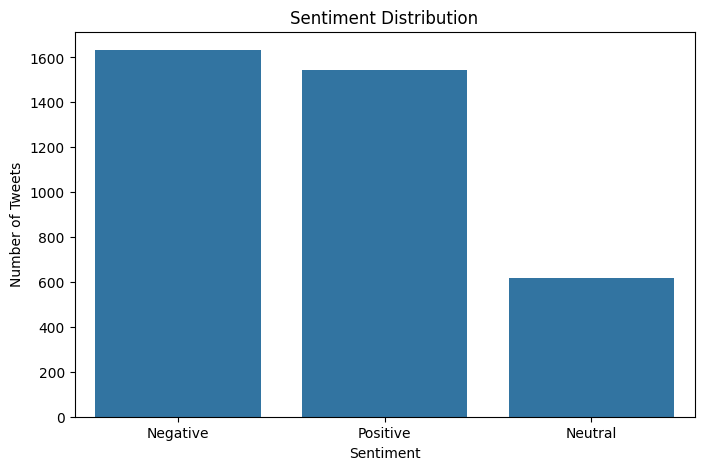

In [ ]:
sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

### **Select Relevant Columns**

Only the OriginalTweet column and the Sentiment column are needed for the task of determining sentiment. All the other columns are not used in the machine learning model.

In [ ]:
df = df[["OriginalTweet", "Sentiment"]]

df.head()

,OriginalTweet,Sentiment
0,TRENDING: New Yorkers encounter empty supermar...,Negative
1,When I couldn't find hand sanitizer at Fred Me...,Positive
2,Find out how you can protect yourself and love...,Positive
3,#Panic buying hits #NewYork City as anxious sh...,Negative
4,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral


### **Text Preprocessing**

The words in the tweet were changed to lowercase to make everything the same. Any marks that are not letters were taken out. The text was broken into words. The common words in the language were removed. These steps help make the data cleaner and let the model pay attention to the words.

In [ ]:
stop_words = set(stopwords.words("english"))

def preprocess_text(text):

    text = text.lower()

    text = text.translate(str.maketrans("", "", string.punctuation))

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

### **Apply Text Preprocessing**

The function, for cleaning text was used on the OriginalTweet column. A new column was created that has the text that was cleaned.

In [ ]:
df["CleanedTweet"] = df["OriginalTweet"].apply(preprocess_text)

df[["OriginalTweet", "CleanedTweet", "Sentiment"]].head()

,OriginalTweet,CleanedTweet,Sentiment
0,TRENDING: New Yorkers encounter empty supermar...,trending new yorkers encounter empty supermark...,Negative
1,When I couldn't find hand sanitizer at Fred Me...,couldnt find hand sanitizer fred meyer turned ...,Positive
2,Find out how you can protect yourself and love...,find protect loved ones coronavirus,Positive
3,#Panic buying hits #NewYork City as anxious sh...,panic buying hits newyork city anxious shopper...,Negative
4,#toiletpaper #dunnypaper #coronavirus #coronav...,toiletpaper dunnypaper coronavirus coronavirus...,Neutral


### **TF-IDF Feature Extraction**

TF-IDF (Term Frequency-Inverse Document Frequency) is used to turn the cleaned text into features that machine learning models can work with. It gives weight to words that appear often in one document but are not seen much in other documents.

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["CleanedTweet"])

y = df["Sentiment"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (3798, 5000)
Target shape: (3798,)


### **Train-Test Split**

The dataset was split into training and testing parts using an 80/20 ratio. The training data is used to teach the machine learning models. The testing data is used to check how well the models perform. The split is done in a way that keeps the distribution of sentiment classes in both parts.



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining sentiment distribution:")
print(y_train.value_counts())

print("\nTesting sentiment distribution:")
print(y_test.value_counts())

Training data shape: (3038, 5000)
Testing data shape: (760, 5000)

Training sentiment distribution:
Sentiment
Negative    1306
Positive    1237
Neutral      495
Name: count, dtype: int64

Testing sentiment distribution:
Sentiment
Negative    327
Positive    309
Neutral     124
Name: count, dtype: int64


### **Model 1 - Multinomial Bayes**

A Multinomial Naive Bayes classifier was trained with the TF-IDF features. This model is often used for text classification because it is fast and handles word frequency data well.

In [ ]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


### **Bayes Model Evaluation**

The Naive Bayes model was evaluated using accuracy, precision, recall, F1-score and a confusion matrix. Each of these metrics helps to understand how well the model performs on aspects of the classification task.

In [ ]:
nb_accuracy = accuracy_score(y_test, nb_predictions)

nb_precision = precision_score(
    y_test,
    nb_predictions,
    average="weighted",
    zero_division=0
)

nb_recall = recall_score(
    y_test,
    nb_predictions,
    average="weighted",
    zero_division=0
)

nb_f1 = f1_score(
    y_test,
    nb_predictions,
    average="weighted",
    zero_division=0
)

print("Accuracy:", nb_accuracy)
print("Precision:", nb_precision)
print("Recall:", nb_recall)
print("F1-Score:", nb_f1)

print("\nClassification Report:\n")
print(classification_report(y_test, nb_predictions, zero_division=0))

Accuracy: 0.6144736842105263
Precision: 0.6792105263157895
Recall: 0.6144736842105263
F1-Score: 0.5595298516561675

Classification Report:

              precision    recall  f1-score   support

    Negative       0.60      0.83      0.69       327
     Neutral       1.00      0.01      0.02       124
    Positive       0.63      0.63      0.63       309

    accuracy                           0.61       760
   macro avg       0.74      0.49      0.45       760
weighted avg       0.68      0.61      0.56       760



### **Naive Bayes Confusion Matrix**

A confusion matrix was created to visualise the number of predictions and the number of incorrect predictions made by the Naive Bayes model for each sentiment class.

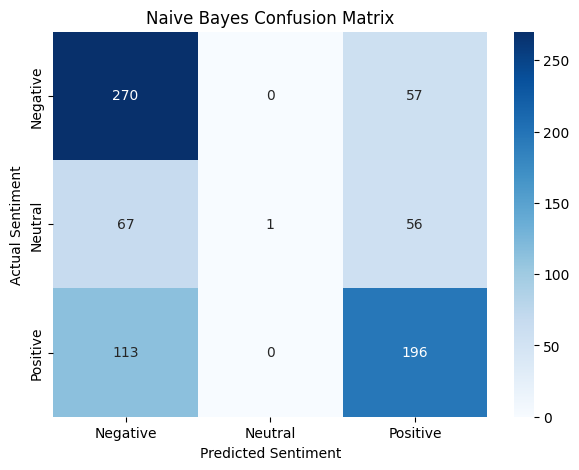

In [ ]:
nb_cm = confusion_matrix(
    y_test,
    nb_predictions,
    labels=["Negative", "Neutral", "Positive"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

### **Model 2 - Logistic Regression**

A Logistic Regression classifier was trained using the TF‑IDF features. Logistic Regression classifier is widely used for text classification. Can effectively learn the relationship, between textual features and sentiment classes.

In [ ]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### **Logistic Regression Model Evaluation**

The Logistic Regression model was evaluated using accuracy, precision, recall, F1-score and a classification report. These metrics help compare the performance of the Logistic Regression model with the Bayes model.

In [ ]:
lr_accuracy = accuracy_score(y_test, lr_predictions)

lr_precision = precision_score(
    y_test,
    lr_predictions,
    average="weighted",
    zero_division=0
)

lr_recall = recall_score(
    y_test,
    lr_predictions,
    average="weighted",
    zero_division=0
)

lr_f1 = f1_score(
    y_test,
    lr_predictions,
    average="weighted",
    zero_division=0
)

print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1-Score:", lr_f1)

print("\nClassification Report:\n")
print(classification_report(y_test, lr_predictions, zero_division=0))

Accuracy: 0.6842105263157895
Precision: 0.7123043013117901
Recall: 0.6842105263157895
F1-Score: 0.66157684245022

Classification Report:

              precision    recall  f1-score   support

    Negative       0.67      0.82      0.74       327
     Neutral       0.90      0.23      0.36       124
    Positive       0.68      0.72      0.70       309

    accuracy                           0.68       760
   macro avg       0.75      0.59      0.60       760
weighted avg       0.71      0.68      0.66       760



### **Logistic Regression Confusion Matrix**

A confusion matrix was created to visualise the correct and incorrect sentiment predictions made by the Logistic Regression model.

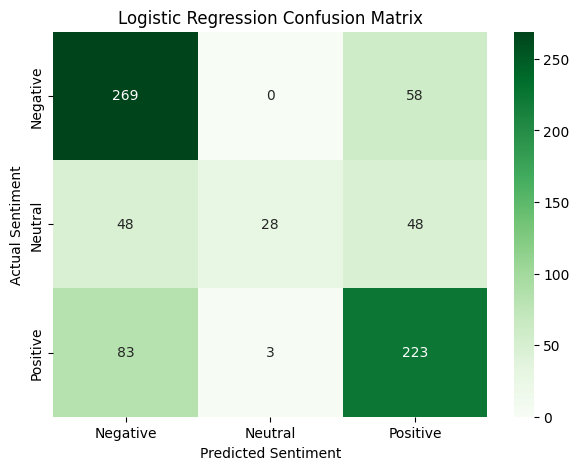

In [ ]:
lr_cm = confusion_matrix(
    y_test,
    lr_predictions,
    labels=["Negative", "Neutral", "Positive"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    lr_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()

### **Model Performance Comparison**

The performance of Naive Bayes and Logistic Regression was compared using weighted accuracy, precision, recall, and F1-score.

In [ ]:
model_comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [nb_accuracy, lr_accuracy],
    "Precision": [nb_precision, lr_precision],
    "Recall": [nb_recall, lr_recall],
    "F1-Score": [nb_f1, lr_f1]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.614474,0.679211,0.614474,0.559530
1,Logistic Regression,0.684211,0.712304,0.684211,0.661577


## **WordCloud Visualisation**

WordClouds were made for each sentiment class to show the words that show up the most, in tweets Negative tweets and Neutral tweets.

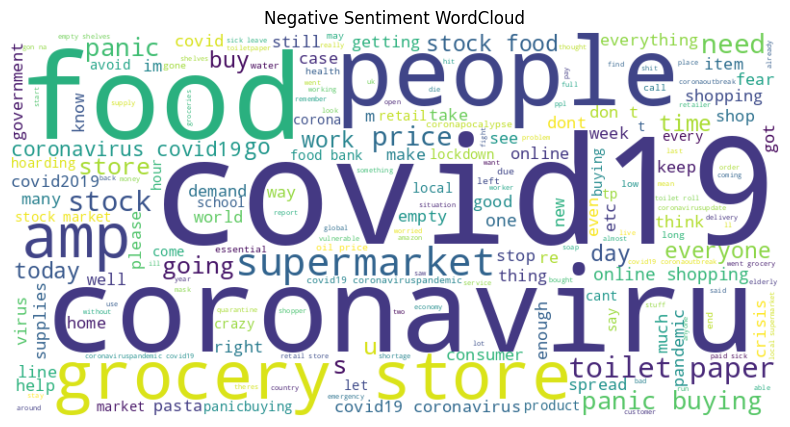

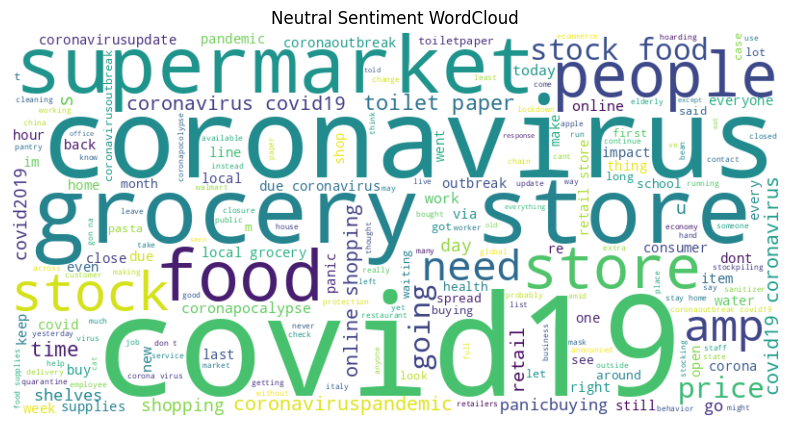

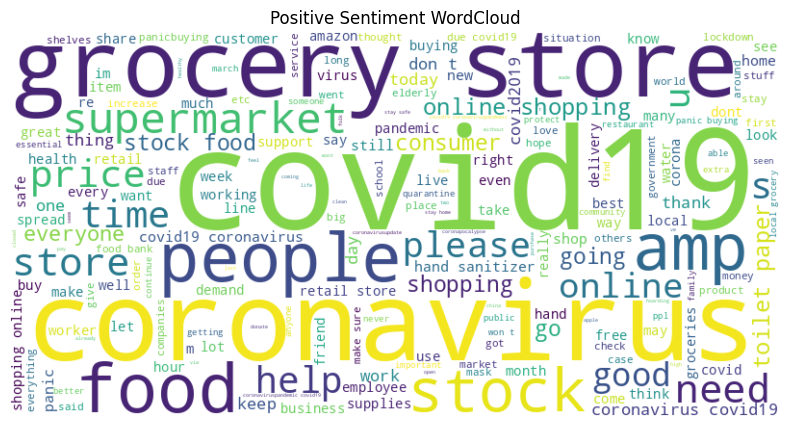

In [ ]:
sentiments = ["Negative", "Neutral", "Positive"]

for sentiment in sentiments:

    text = " ".join(
        df[df["Sentiment"] == sentiment]["CleanedTweet"]
    )

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(10, 5))

    plt.imshow(wordcloud, interpolation="bilinear")

    plt.axis("off")

    plt.title(f"{sentiment} Sentiment WordCloud")

    plt.show()

### **Error Analysis**

The Logistic Regression model was chosen for error analysis because it gave the overall results. We looked at five tweets that the model got wrong by comparing the sentiment labels with the models predictions.

In [ ]:
error_analysis = pd.DataFrame({
    "Original Tweet": df.loc[y_test.index, "OriginalTweet"],
    "Actual Sentiment": y_test,
    "Predicted Sentiment": lr_predictions
})

misclassified = error_analysis[
    error_analysis["Actual Sentiment"] != error_analysis["Predicted Sentiment"]
]

misclassified.head(5)

,Original Tweet,Actual Sentiment,Predicted Sentiment
137,@sainsburys Can you please make sure that in t...,Negative,Positive
1709,We as a species are so fuckign stupid that we ...,Negative,Positive
286,@Rhett800cc So hard to decide??. As much as I ...,Negative,Positive
3619,"""We are still building additional gyms and pro...",Positive,Negative
906,Airlines grounded. Stock market plummeting. Ev...,Positive,Negative


### **Discussion of Misclassified Tweets**

The tweets that were misclassified show some of the problems with sentiment analysis. Tweets can have feelings, sarcasm, casual language, spelling errors or situations that the model finds hard to understand. For example a negative tweet that has words that're usually in positive messages might be labeled as Positive. Also a tweet that has words like "grounded" or "plummeting" might be labeled as Negative even if the actual sentiment is Positive.

These mistakes show a problem, with machine learning models that use TF-IDF. These models look mostly at words and how often they appear instead of really understanding the meaning and context of the whole sentence.

## **Conclusion**

This project built a sentiment classification system that classifies tweets into Positive, Negative or Neutral. The text data was cleaned by converting all letters to lowercase removing punctuation marks breaking the text into tokens and dropping stopwords. TF‑IDF was then applied to transform the cleaned text into features.

Two machine learning models were. Evaluated: Multinomial Naive Bayes and Logistic Regression. Logistic Regression performed better than Multinomial Naive Bayes reaching an accuracy of sixty‑eight point forty‑two percent and a weighted F1‑score of about sixty‑six point sixteen percent.

The results show that Logistic Regression was more effective at separating the three sentiment classes. Neutral tweets stayed hard to classify accurately.

A sentiment classification system like this can be used by businesses and organisations to analyse customer feedback watch opinion, on social media understand how satisfied customers are and spot common positive or negative trends.